# BirdCLEF 2026 Dataset - Baseline EDA

## Notes from Kaggle
1. Some species in hidden test may appear only in labeled `train_soundscapes` and not in clean `train_audio`.
2. One `inat_taxon_id` can map to multiple `primary_label` values (including sonotypes).
3. True recording location for soundscapes is Pantanal, while clean `train` recordings are globally distributed.
4. `secondary_labels` can be incomplete.
5. iNaturalist samples do not provide `rating`.

In [51]:
import ast 
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown, Audio

from pathlib import Path
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.notebooks.eda import *
from birdclef_2026_ml.paths import load_project_paths


paths = load_project_paths()

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
train = pd.read_csv(paths.metadata_train)
taxonomy = pd.read_csv(paths.taxonomy)
soundscape_labels = pd.read_csv(paths.metadata_soundscapes)
sample_submission = pd.read_csv(paths.sample_submission)

print(f"Train: {train.duplicated().sum()} duplicates")
print(f"Taxonomy: {taxonomy.duplicated().sum()} duplicates")
print(f"Soundscape labels: {soundscape_labels.duplicated().sum()} duplicates")

train = pd.read_parquet(paths.train_processed)
soundscape_labels = pd.read_parquet(paths.soundscapes_processed)

print('train shape:', train.shape)
print('taxonomy shape:', taxonomy.shape)
print('soundscape_labels shape:', soundscape_labels.shape)
print('sample_submission shape:', sample_submission.shape)

display(Markdown("### Train"))
display(train.head())
display(Markdown("### Taxonomy"))
display(taxonomy.head())
display(Markdown("### Soundscape labels"))
display(soundscape_labels.head())
display(Markdown("### Sample submission"))
display(sample_submission.head())

Train: 0 duplicates
Taxonomy: 0 duplicates
Soundscape labels: 739 duplicates
train shape: (31991, 19)
taxonomy shape: (234, 5)
soundscape_labels shape: (739, 12)
sample_submission shape: (3, 235)


### Train

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,primary_label_int,class_name_int,duration,duration_trim
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,0.0,2.0,18.024,17.992
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,0.0,2.0,28.392,28.360
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,0.0,2.0,80.016,79.984
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,0.0,2.0,61.272,61.240
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,0.0,2.0,71.064,71.032


### Taxonomy

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


### Soundscape labels

,filename,start,end,primary_label,primary_label_list,site,datetime,start_sec,end_sec,class_name_list,primary_label_int_list,class_name_int_list
index,,,,,,,,,,,,
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,0.0,5.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,5.0,10.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4773211200,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,10.0,15.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4773211264,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,15.0,20.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4773211008,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,20.0,25.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]


### Sample submission

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [60]:
filename = train[train["class_name"] == "Mammalia"].iloc[10]["filename"]
Audio(filename=paths.train_audio_dir / filename)

In [57]:
train[train["class_name"] == "Mammalia"]

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,primary_label_int,class_name_int,duration,duration_trim
28,209233,[],[],49.2473,-107.7249,Equus caballus,Feral Horse,Mammalia,209233,Sam,cc-by-nc,NaN,https://static.inaturalist.org/sounds/864998.m...,209233/iNat864998.ogg,iNat,5.0,3.0,17.182781,17.150781
480,41970,[],[],-19.4260,-56.1549,Panthera onca,Jaguar,Mammalia,41970,George Vlad,by-nc-sa,5.0,https://xeno-canto.org/992981/download,41970/XC992981.ogg,XC,27.0,3.0,92.808000,91.536000
481,41970,[],[alarm call],-8.2542,-63.9717,Panthera onca,Jaguar,Mammalia,41970,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,2.0,https://xeno-canto.org/1044064/download,41970/XC1044064.ogg,XC,27.0,3.0,42.736000,42.704000
482,41970,[],[],-3.3431,-72.8819,Panthera onca,Jaguar,Mammalia,41970,Jordan Wolf,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1226073....,41970/iNat1226073.ogg,iNat,27.0,3.0,14.065469,14.065469
483,41970,[],[call],-1.7939,-77.8101,Panthera onca,Jaguar,Mammalia,41970,Cedric Mroczko,by-nc-sa,2.0,https://xeno-canto.org/564865/download,41970/XC564865.ogg,XC,27.0,3.0,76.068562,75.632000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,74113,[],[],56.0058,47.5081,Bos taurus,Highland,Mammalia,74113,Константин,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1463593....,74113/iNat1463593.ogg,iNat,69.0,3.0,5.241906,5.081906
671,74113,[],[sniffing],59.5427,18.1549,Bos taurus,Highland,Mammalia,74113,Teet Sirotkin,by-nc-sa,5.0,https://xeno-canto.org/1039325/download,74113/XC1039325.ogg,XC,69.0,3.0,22.536625,22.536625
672,74580,[],[],-16.5567,-56.7287,Mico melanurus,Black-tailed Marmoset,Mammalia,74580,MarcosHalemFelix,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1152501....,74580/iNat1152501.ogg,iNat,70.0,3.0,4.690437,4.658437
673,74580,[],[social call],-15.0055,-59.9478,Mico melanurus,Black-tailed Marmoset,Mammalia,74580,Guilherme Melo,by-nc-sa,3.0,https://xeno-canto.org/991442/download,74580/XC991442.ogg,XC,70.0,3.0,32.361625,32.208000


In [4]:
# Compare number of files on disk vs unique filenames in metadata
train_audio_dir = Path(paths.train_audio_dir)
train_soundscapes_dir = Path(paths.train_soundscapes_dir)

train_audio_files_on_disk = sum(1 for p in train_audio_dir.rglob("*.ogg") if p.is_file() and (not p.name.startswith("._")))
train_soundscapes_files_on_disk = sum(1 for p in train_soundscapes_dir.rglob("*.ogg") if p.is_file() and (not p.name.startswith("._")))

train_unique_filenames = train["filename"].nunique()
soundscape_unique_filenames = soundscape_labels["filename"].nunique()

comparison = pd.DataFrame(
    {
        "directory": ["train_audio_dir", "train_soundscapes_dir"],
        "files_on_disk": [train_audio_files_on_disk, train_soundscapes_files_on_disk],
        "unique_filenames_in_metadata": [train_unique_filenames, soundscape_unique_filenames],
    }
)
comparison["difference_disk_minus_metadata"] = (
    comparison["files_on_disk"] - comparison["unique_filenames_in_metadata"]
)

display(comparison)

,directory,files_on_disk,unique_filenames_in_metadata,difference_disk_minus_metadata
0,train_audio_dir,35549,31991,3558
1,train_soundscapes_dir,10658,66,10592


In [5]:
display(Markdown("### Train"))
display(summarize_df(train))
display(Markdown("### Taxonomy"))
display(summarize_df(taxonomy))
display(Markdown("### Soundscape labels"))
display(summarize_df(soundscape_labels))

### Train

,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
primary_label,object,0,0.000000,206.0,NaN,NaN,NaN
secondary_labels,object,0,0.000000,NaN,0.187834,0.0,8.0
type,object,0,0.000000,NaN,0.746210,0.0,7.0
latitude,float64,0,0.000000,14232.0,NaN,NaN,NaN
longitude,float64,0,0.000000,14207.0,NaN,NaN,NaN
scientific_name,object,0,0.000000,206.0,NaN,NaN,NaN
common_name,object,0,0.000000,206.0,NaN,NaN,NaN
class_name,object,0,0.000000,5.0,NaN,NaN,NaN
inat_taxon_id,int64,0,0.000000,206.0,NaN,NaN,NaN
author,object,1159,3.622894,3749.0,NaN,NaN,NaN


### Taxonomy

,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
primary_label,str,0,0.0,234.0,NaN,NaN,NaN
inat_taxon_id,int64,0,0.0,210.0,NaN,NaN,NaN
scientific_name,str,0,0.0,234.0,NaN,NaN,NaN
common_name,str,0,0.0,234.0,NaN,NaN,NaN
class_name,str,0,0.0,5.0,NaN,NaN,NaN


### Soundscape labels

,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
filename,object,0,0.0,66.0,NaN,NaN,NaN
start,object,0,0.0,12.0,NaN,NaN,NaN
end,object,0,0.0,12.0,NaN,NaN,NaN
primary_label,object,0,0.0,251.0,NaN,NaN,NaN
primary_label_list,object,0,0.0,NaN,4.224628,1.0,10.0
site,int32,0,0.0,9.0,NaN,NaN,NaN
datetime,"datetime64[us, UTC]",0,0.0,62.0,NaN,NaN,NaN
start_sec,float64,0,0.0,12.0,NaN,NaN,NaN
end_sec,float64,0,0.0,12.0,NaN,NaN,NaN
class_name_list,object,0,0.0,NaN,1.353180,1.0,3.0


In [6]:
# Same taxonomy id -> different primary labels (different sonotypes)
display(taxonomy.groupby("inat_taxon_id")["primary_label"].nunique().sort_values())
display(taxonomy[taxonomy["inat_taxon_id"] == 47158].head(5))

inat_taxon_id
7           1
22961       1
22967       1
22973       1
22983       1
           ..
14306       1
14344       1
11281       1
1595929     1
47158      25
Name: primary_label, Length: 210, dtype: int64

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
30,47158son01,47158,Insect son01,Insect sonotype01,Insecta
31,47158son02,47158,Insect son02,Insect sonotype02,Insecta
32,47158son03,47158,Insect son03,Insect sonotype03,Insecta
33,47158son04,47158,Insect son04,Insect sonotype04,Insecta
34,47158son05,47158,Insect son05,Insect sonotype05,Insecta


### 1. Train metadata


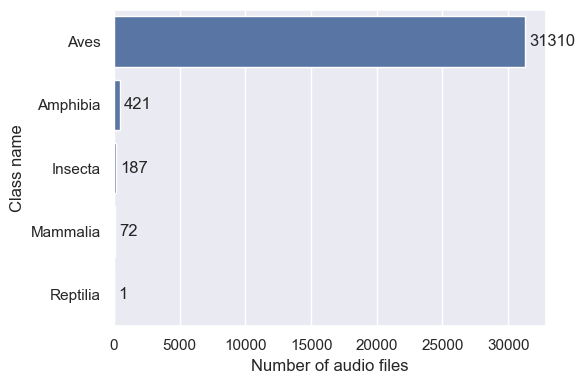

In [4]:
cols = ["class_name", "common_name"]

counts = {
    col: train.groupby(col)["filename"].nunique().sort_values(ascending=False)
    for col in cols
}

fig = plt.figure(figsize=(6, 4))
top_counts_class = counts["class_name"].reset_index(name="n_files")

ax = sns.barplot(
    data=top_counts_class,
    x="n_files",
    y="class_name"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_xlabel("Number of audio files")
ax.set_ylabel("Class name")

plt.tight_layout()
fig.savefig("plots/data_exploration/class_name_filenames.pdf", bbox_inches="tight")

In [6]:
counts

{'class_name': class_name
 Aves        31310
 Amphibia      421
 Insecta       187
 Mammalia       72
 Reptilia        1
 Name: filename, dtype: int64,
 'common_name': common_name
 Southern Lapwing              459
 Bananaquit                    454
 Ferruginous Pygmy Owl         451
 Saffron Finch                 447
 Boat-billed Flycatcher        447
                              ... 
 Hooded Capuchin                 1
 Feral Horse                     1
 Central Dwarf Frog              1
 Southern Spectacled Caiman      1
 Waxy Monkey Tree Frog           1
 Name: filename, Length: 206, dtype: int64}

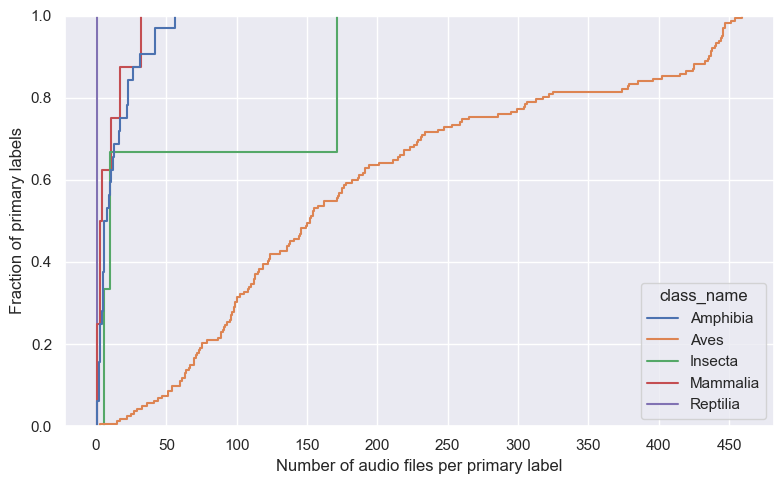

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = (
    train.groupby(["class_name", "common_name"])["filename"]
    .nunique()
    .rename("n_files")
    .reset_index()
)

sns.ecdfplot(
    data=plot_df,
    x="n_files",
    hue="class_name",
    ax=ax,
)

xmin, xmax = ax.get_xlim()
xticks = list(ax.get_xticks()) + [50, 150, 200, 250, 350, 450]
ax.set_xticks(sorted(set(xticks)))
ax.set_xlim(xmin, xmax)

#ax.set_title("ECDF of primary label frequencies")
ax.set_xlabel("Number of audio files per primary label")
ax.set_ylabel("Fraction of primary labels")
plt.tight_layout()
fig.savefig("plots/data_exploration/ecdf_primary_label.pdf", bbox_inches="tight")

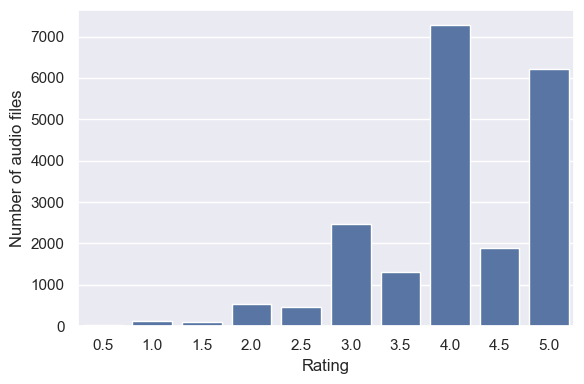

In [30]:
rating_counts = train["rating"].dropna().value_counts().sort_index()

fig=plt.figure(figsize=(6, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
#plt.title("Distribution of quality ratings in train")
plt.xlabel("Rating")
plt.ylabel("Number of audio files")
plt.tight_layout()
fig.savefig("plots/data_exploration/rating_filenames.pdf", bbox_inches="tight")

Train rows with valid coordinates: 31991 / 31991
Latitude range: (np.float64(-54.8574), np.float64(64.8635))
Longitude range: (np.float64(-159.5029), np.float64(175.3239))
class_name categories: 5


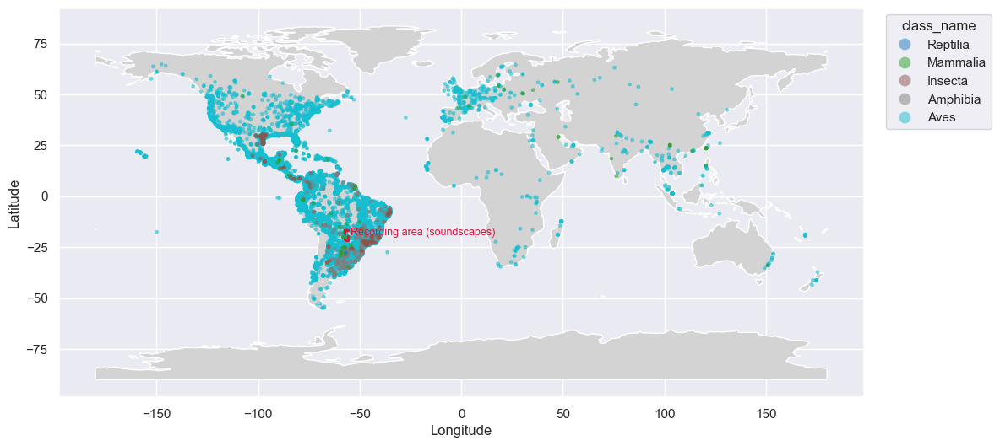

In [29]:
fig = plot_train_locations(train, hue_col='class_name')
fig.savefig("plots/data_exploration/map_class_name.jpg", bbox_inches="tight", dpi=300)

In [16]:
diff = np.setdiff1d(train["secondary_labels"].explode().dropna().astype(str).unique(),
             train["primary_label"].astype(str).unique())

print("Labels that are in secondary labels and not in primary:", diff)

Labels that are in secondary labels and not in primary: []


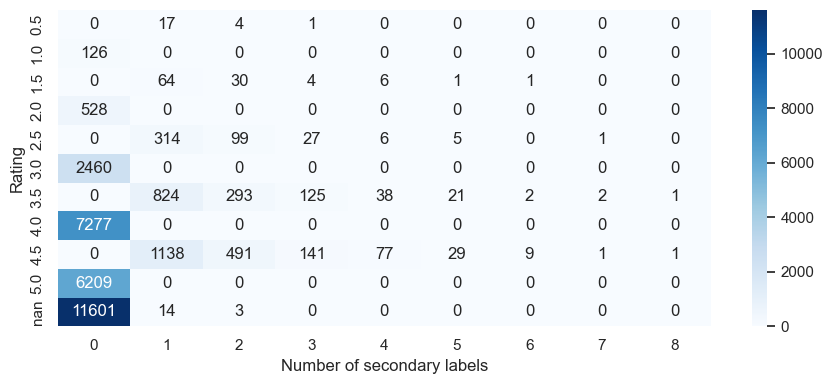

In [31]:
train["secondary_labels_len"] = train["secondary_labels"].map(lambda x: len(x) if isinstance(x, list) else 0)

ct = pd.crosstab(train["rating"], train["secondary_labels_len"], dropna=False)
fig=plt.figure(figsize=(9, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
#plt.title("Rating vs number of secondary labels")
plt.xlabel("Number of secondary labels")
plt.ylabel("Rating")
plt.tight_layout()
fig.savefig("plots/data_exploration/rating_secondary_label.jpg", bbox_inches="tight", dpi=150)

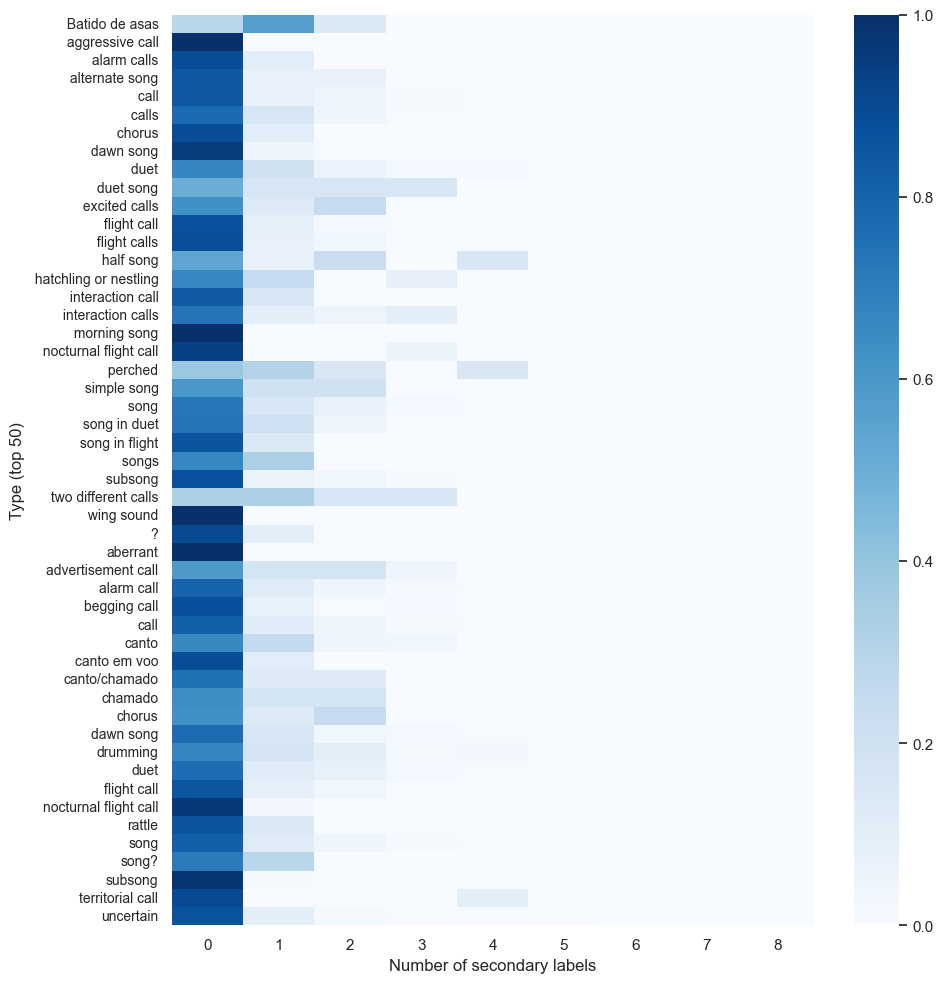

In [32]:
train_subset = train.explode("type").reset_index(drop=True)

top_n = 50
top_types = train_subset["type"].value_counts().head(top_n).index
train_subset = train_subset[train_subset["type"].isin(top_types)]

ct = pd.crosstab(train_subset["type"], train_subset["secondary_labels_len"], normalize="index")

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(ct, annot=False, cmap="Blues", ax=ax)

#ax.set_title("Types vs number of secondary labels")
ax.set_ylabel(f"Type (top {top_n})")
ax.set_xlabel("Number of secondary labels")

ax.set_yticks(np.arange(ct.shape[0]) + 0.5)
ax.set_yticklabels(ct.index, fontsize=10)

plt.tight_layout()
fig.savefig("plots/data_exploration/type_secondary_labels.jpg", bbox_inches="tight", dpi=150)

### 2. Soundscape Labels

In [90]:
mlb = MultiLabelBinarizer() # multi-hot encoding
Y = mlb.fit_transform(soundscape_labels["primary_label_list"])
Y_class = MultiLabelBinarizer().fit_transform(soundscape_labels["class_name_list"])

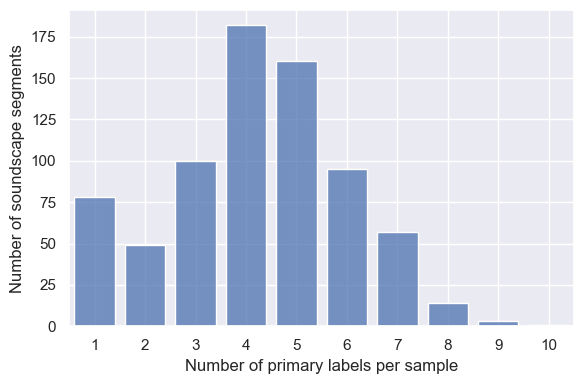

In [68]:
counts = Y.sum(axis=1)

mn, mx = counts.min(), counts.max()

# bins centered on integers
bins = np.arange(mn - 0.5, mx + 1.5, 1)

fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    counts,
    bins=bins,
    discrete=True,
    shrink=0.8,
    ax=ax,
)

ax.set_xticks(np.arange(mn, mx + 1))
ax.set_xlim(mn - 0.5, mx + 0.5)

#ax.set_title("Number of primary labels per soundscape sample")
ax.set_xlabel("Number of primary labels per sample")
ax.set_ylabel("Number of soundscape segments")

plt.tight_layout()
fig.savefig("plots/data_exploration/ss_primary_label.pdf", bbox_inches="tight")

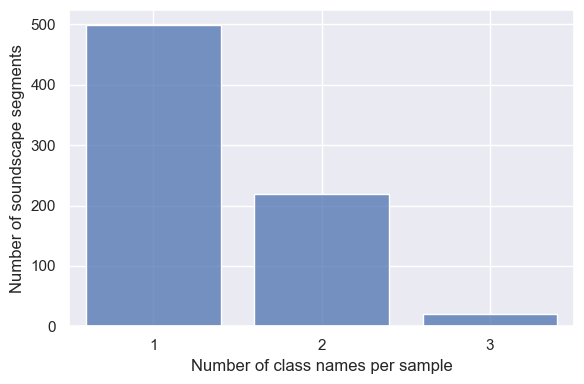

In [74]:
counts = Y_class.sum(axis=1)

mn, mx = counts.min(), counts.max()

# bins centered on integers
bins = np.arange(mn - 0.5, mx + 1.5, 1)

fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    counts,
    bins=bins,
    discrete=True,
    shrink=0.8,
    ax=ax,
)

ax.set_xticks(np.arange(mn, mx + 1))
ax.set_xlim(mn - 0.5, mx + 0.5)

#ax.set_title("Number of class names per soundscape sample")
ax.set_xlabel("Number of class names per sample")
ax.set_ylabel("Number of soundscape segments")

plt.tight_layout()
fig.savefig("plots/data_exploration/ss_class_name.pdf", bbox_inches="tight")

Number of classes in soundscapes: 75
Number of classes in train: 206


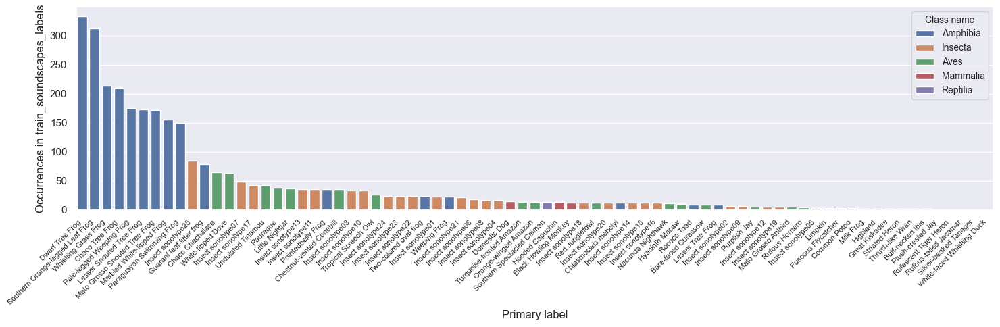

In [87]:
print("Number of classes in soundscapes:", len(mlb.classes_))
print("Number of classes in train:", train["primary_label"].nunique())

# Build dataframe
df = (
    pd.DataFrame({
        "primary_label": mlb.classes_,
        "count": Y.sum(axis=0),
    })
    .merge(
        taxonomy[["primary_label", "class_name", "common_name"]],
        on="primary_label",
        how="left",
    )
    .sort_values("count", ascending=False)
)

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data=df,
    x="common_name",
    y="count",
    hue="class_name",
    dodge=False,
    ax=ax,
)

ax.set_xlabel("Primary label")
ax.set_ylabel("Occurrences in train_soundscapes_labels")

plt.xticks(
    rotation=45,
    ha="right",   
    fontsize=8,
)

ax.legend(
    title="Class name",
    loc="upper right",
    fontsize=10,
    title_fontsize=10,
)

plt.tight_layout()
fig.savefig("plots/data_exploration/ss_primary_label.pdf", bbox_inches="tight")

In [15]:
soundscape_labels

,filename,start,end,primary_label,primary_label_list,site,datetime,start_sec,end_sec,class_name_list,primary_label_int_list,class_name_int_list
index,,,,,,,,,,,,
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,0.0,5.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,5.0,10.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4696909696,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,10.0,15.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4696909632,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,15.0,20.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
4696909760,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",22,2021-12-31 20:15:00+00:00,20.0,25.0,[Amphibia],"[8, 15, 21, 57, 63]",[0]
...,...,...,...,...,...,...,...,...,...,...,...,...
4696796224,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",22,2022-02-19 20:00:00+00:00,35.0,40.0,[Amphibia],"[60, 63]",[0]
4696796288,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,40.0,45.0,[Amphibia],"[57, 60]",[0]
4696796352,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",22,2022-02-19 20:00:00+00:00,45.0,50.0,[Amphibia],"[57, 60]",[0]


/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_86779/2677240524.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


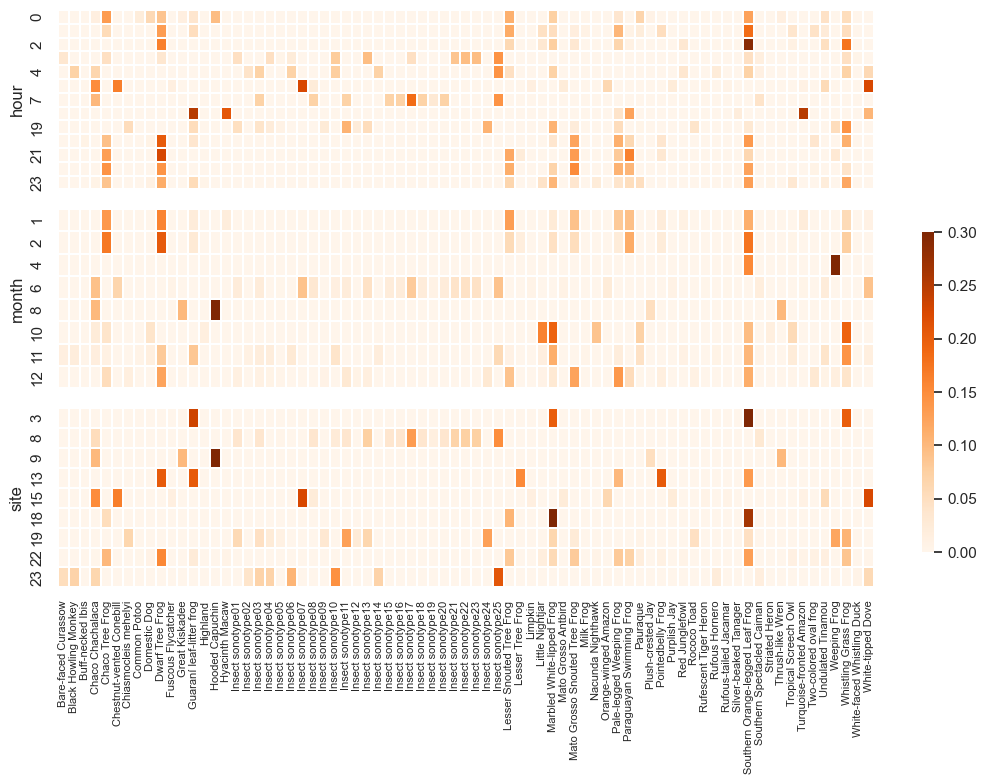

In [50]:
# Common name composition by site and month (row-normalized)
sl = soundscape_labels[["datetime", "site", "primary_label_list"]].explode("primary_label_list")
sl = sl.merge(taxonomy, left_on="primary_label_list", right_on="primary_label")
sl["hour"] = sl["datetime"].dt.hour
sl["month"] = sl["datetime"].dt.month

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
cbar_ax = fig.add_axes([0.93, 0.3, 0.012, 0.4])

for i, col in enumerate(["hour", "month", "site"]):
    pivot = sl.groupby([col, "common_name"]).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    show_cbar = i == 0

    sns.heatmap(
        pivot,
        cmap="Oranges",
        linewidths=0.1,
        vmin=0,
        vmax=0.3,
        ax=axes[i],
        cbar=show_cbar,
        cbar_ax=cbar_ax if show_cbar else None,
    )
    axes[i].set_xticks(np.arange(pivot.shape[1]) + 0.5)
    axes[i].set_xticklabels(pivot.columns, rotation=90)
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].set_xlabel("")

plt.tight_layout(rect=[0, 0, 0.9, 1])
fig.savefig("plots/data_exploration/ss_hour_month_site.jpg", bbox_inches="tight", dpi=150)

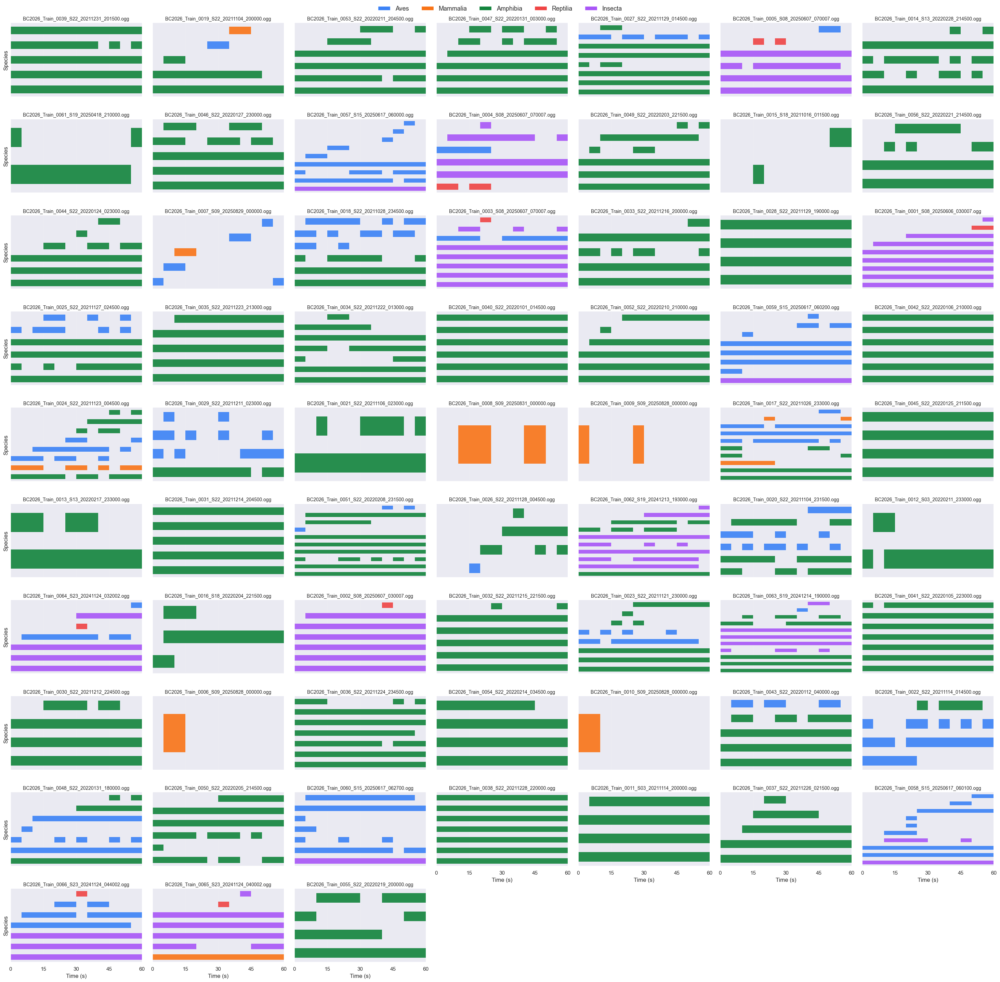

In [61]:
from matplotlib.patches import Patch

g = sns.FacetGrid(
    soundscape_labels,
    col="filename",
    col_wrap=7,
    sharex=True,
    sharey=False,
    height=3,
    aspect=1.4,
)

class_colors = {
        "Aves": "#3B82F6",
        "Mammalia": "#F97316",
        "Amphibia": "#12843C",
        "Reptilia": "#EF4444",
        "Insecta": "#A855F7",
    }

def draw_timeline(data, **kws):
    fname = data["filename"].iloc[0]

    plot_soundscape_species_activity(
        soundscapes=data,
        taxonomy=taxonomy,
        filename=fname,
        class_colors=class_colors,
        ax=plt.gca(),
        show_legend=False,
        title=fname  
    )


g.map_dataframe(draw_timeline)

# common x ticks every 15 seconds
xticks = np.arange(0, 61, 15)

n_axes = len(g.axes.flat)

for i, ax in enumerate(g.axes.flat):
    ax.set_xticks(xticks)

g.set_axis_labels("Time (s)", "Species")

# --- legend at top ---
legend_handles = [
    Patch(facecolor=color, label=cls)
    for cls, color in class_colors.items()
]

g.figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=len(class_colors),
    frameon=False,
    fontsize=13,
)

# leave space for legend
plt.tight_layout(rect=[0, 0, 1, 0.95])
g.figure.savefig("plots/data_exploration/ss_full_timestamps.pdf", bbox_inches="tight")

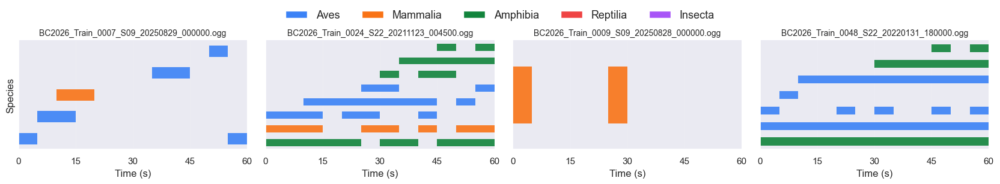

In [112]:
filenames_subset = [
    "BC2026_Train_0048_S22_20220131_180000.ogg",
    "BC2026_Train_0007_S09_20250829_000000.ogg",
    "BC2026_Train_0009_S09_20250828_000000.ogg",
    "BC2026_Train_0024_S22_20211123_004500.ogg",
]
ss_subset = soundscape_labels[soundscape_labels["filename"].isin(filenames_subset)]

g = sns.FacetGrid(
    ss_subset,
    col="filename",
    col_wrap=4,
    sharex=True,
    sharey=False,
    height=3,
    aspect=1.4,
)

class_colors = {
        "Aves": "#3B82F6",
        "Mammalia": "#F97316",
        "Amphibia": "#12843C",
        "Reptilia": "#EF4444",
        "Insecta": "#A855F7",
    }

def draw_timeline(data, **kws):
    fname = data["filename"].iloc[0]

    plot_soundscape_species_activity(
        soundscapes=data,
        taxonomy=taxonomy,
        filename=fname,
        class_colors=class_colors,
        ax=plt.gca(),
        show_legend=False,
        title=fname  
    )


g.map_dataframe(draw_timeline)

# common x ticks every 15 seconds
xticks = np.arange(0, 61, 15)

n_axes = len(g.axes.flat)

for i, ax in enumerate(g.axes.flat):
    ax.set_xticks(xticks)

g.set_axis_labels("Time (s)", "Species")

# --- legend at top ---
legend_handles = [
    Patch(facecolor=color, label=cls)
    for cls, color in class_colors.items()
]

g.figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(class_colors),
    frameon=False,
    fontsize=13,
)

# leave space for legend
plt.tight_layout(rect=[0, 0, 1, 0.95])
g.figure.savefig("plots/data_exploration/ss_extract_timestamps.pdf", bbox_inches="tight")

### 3. Taxonomy

In [124]:
fig = px.treemap(
    taxonomy,
    path=["class_name", "common_name"],
)

fig.update_traces(
    textfont_size=16,
    textinfo="label",
    textposition="middle center",
)

fig.update_layout(
    margin=dict(t=0, l=0, r=0, b=0),
)

fig.show()
fig.write_html("plots/data_exploration/taxonomy_treemap.html")

### 4. Audio (train)

In [10]:
from birdclef_2026_ml.processing.audio_utils import get_duration
train_raw = pd.read_csv(paths.metadata_train)
train_raw["duration"] = train_raw["filename"].apply(lambda x : get_duration(x, pathroot="../data/raw/train_audio"))

Duration (s): min=0.01, max=6881.10, mean=34.88, median=21.00
Duration percentiles (5%, 95%): 4.10, 103.58


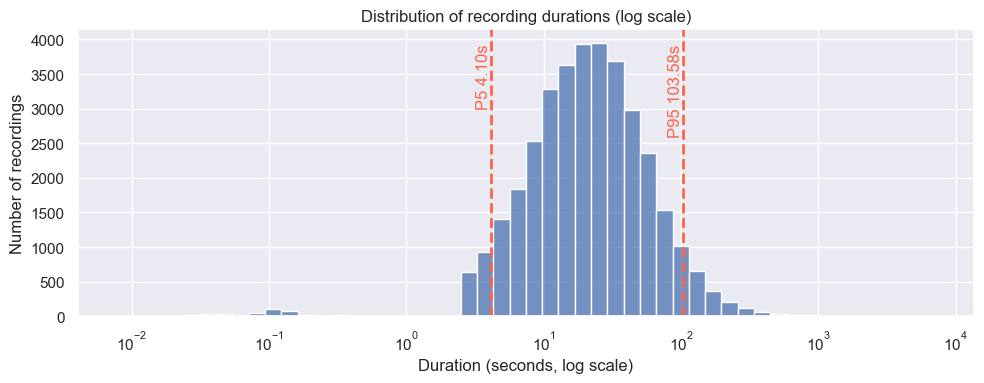

In [63]:
dur = train_raw["duration"]
print(
    "Duration (s): "
    f"min={dur.min():.2f}, "
    f"max={dur.max():.2f}, "
    f"mean={dur.mean():.2f}, "
    f"median={dur.median():.2f}"
)

p5, p95 = np.percentile(dur, [5, 95])
print(f"Duration percentiles (5%, 95%): {p5:.2f}, {p95:.2f}")

fig=plt.figure(figsize=(10, 4))
ax = plt.gca()
sns.histplot(train_raw["duration"], log_scale=True, bins=50)
ax.axvline(p5, color="tomato", linestyle="--", linewidth=2)
ax.axvline(p95, color="tomato", linestyle="--", linewidth=2)

y_max = ax.get_ylim()[1]
ax.text(p5, y_max * 0.95, f"P5 {p5:.2f}s", color="tomato", rotation=90, va="top", ha="right")
ax.text(p95, y_max * 0.95, f"P95 {p95:.2f}s", color="tomato", rotation=90, va="top", ha="right")
plt.title("Distribution of recording durations (log scale)")
plt.xlabel("Duration (seconds, log scale)")
plt.ylabel("Number of recordings")
plt.tight_layout()
fig.savefig("plots/data_exploration/duration.pdf", bbox_inches="tight")

In [142]:
shortest = train_raw.sort_values("duration")["filename"].head(5)

for filename in shortest:
    display(Audio(filename=paths.train_audio_dir / filename))

#### Duration Tail Analysis

Some recordings are very short or very long. This step checks whether tail-heavy durations are concentrated in specific species or broadly distributed across many species.

In [59]:
# Species-level summary
species_stats = (
    train_raw.groupby("primary_label")["duration"]
    .agg(min="min", max="max", mean="mean", count="count")
    .reset_index()
)

# Ratios of durations relative to global percentiles
def tail_ratio(group):
    durations = group["duration"]
    return pd.Series({
        "ratio_below_p5": (durations < p5).mean(),
        "ratio_above_p95": (durations > p95).mean()
    })

tail_stats = (
    train_raw.groupby("primary_label")
    .apply(tail_ratio)
    .reset_index()
)

# Species entirely outside percentile bounds
below_p5 = species_stats[species_stats["max"] < p5]
above_p95 = species_stats[species_stats["min"] > p95]

# Species mostly in tails
mostly_short = tail_stats[tail_stats["ratio_below_p5"] > 0.8]
mostly_long = tail_stats[tail_stats["ratio_above_p95"] > 0.8]

print(
    f"Species entirely below p5: {len(below_p5)}\n"
    f"Species entirely above p95: {len(above_p95)}\n"
    f"Species mostly below p5 (>80%): {len(mostly_short)}\n"
    f"Species mostly above p95 (>80%): {len(mostly_long)}"
)

print(len(train_raw), len(train_raw[(train_raw["duration"] > p5) & (train_raw["duration"] < p95)]))

Species entirely below p5: 0
Species entirely above p95: 0
Species mostly below p5 (>80%): 0
Species mostly above p95 (>80%): 0
35549 31991


#### Audio examples

##### By class_name

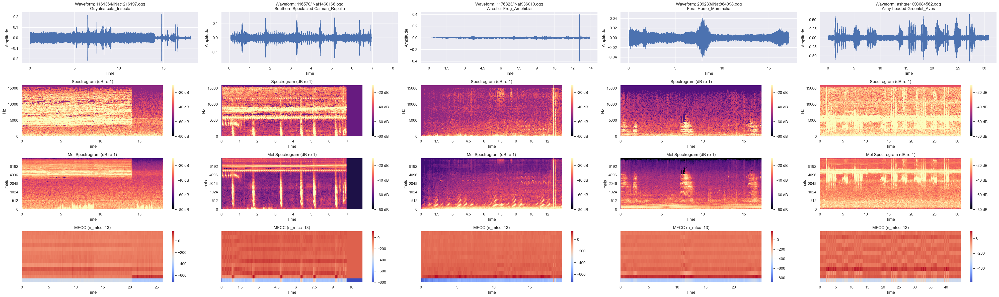

In [38]:
# By class_name
train_slice = train.groupby('class_name', sort=False, as_index=False).first()

n_cols = len(train_slice)
example_paths = train_slice['filename'].tolist()
extra_titles = (train_slice['common_name'].astype(str) + '_' + train_slice['class_name'].astype(str)).tolist()

for path in example_paths:
    display(Audio(filename=paths.train_audio_dir / path))

fig = plot_audio_overview_grid(example_paths, paths.train_audio_dir, n_cols=n_cols, extra_titles=extra_titles)
fig.savefig("plots/data_exploration/audio_grid_class_name.jpg", bbox_inches="tight", dpi=150)

##### 5 different recordings of the same species

,primary_label,common_name,rating,filename
24875,soulap1,Southern Lapwing,5.0,soulap1/XC433638.ogg
25283,soulap1,Southern Lapwing,5.0,soulap1/XC47141.ogg
25044,soulap1,Southern Lapwing,4.0,soulap1/XC782667.ogg
24969,soulap1,Southern Lapwing,NaN,soulap1/iNat835910.ogg
24999,soulap1,Southern Lapwing,NaN,soulap1/iNat634739.ogg


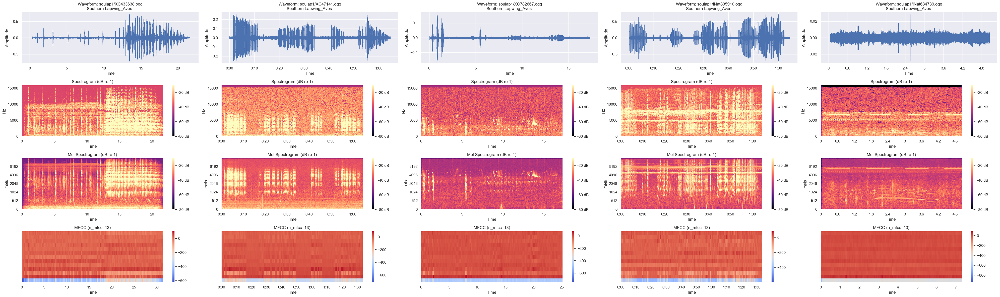

In [37]:
# Pick one primary_label that has at least 5 recordings
label_counts = train["primary_label"].value_counts()
selected_label = label_counts[label_counts >= 5].index[0] 

train_slice = (
    train[train["primary_label"] == selected_label]
    .sample(5, random_state=42)   # 5 recordings of the same primary label
    .sort_values("rating", ascending=False)
)
example_paths = train_slice["filename"].tolist()
extra_titles = (
    train_slice["common_name"].astype(str) + "_"
    + train_slice["class_name"].astype(str) + " "
).tolist()

for path in example_paths:
    display(Audio(filename=paths.train_audio_dir / path))

fig = plot_audio_overview_grid(example_paths, paths.train_audio_dir, n_cols=5, extra_titles=extra_titles)
display(train_slice[["primary_label", "common_name", "rating", "filename"]])
fig.savefig("plots/data_exploration/audio_grid_primary_label.jpg", bbox_inches="tight", dpi=150)

### Primary labels taxonomy & train

In [ ]:
taxonomy_labels = taxonomy["primary_label"].unique()
train_labels = train["primary_label"].unique()
ss_labels = soundscape_labels["primary_label_list"].explode().unique()

not_in_train = np.setdiff1d(taxonomy_labels, train_labels)
display(Markdown("#### Labels that are not in train, but in soundscapes:"))
print(np.intersect1d(not_in_train, ss_labels))
display(Markdown("#### Taxonomy of labels that are not in train"))
taxonomy[taxonomy["primary_label"].isin(not_in_train)]

#### Labels that are not in train, but in soundscapes:

['1491113' '25073' '47158son01' '47158son02' '47158son03' '47158son04'
 '47158son05' '47158son06' '47158son07' '47158son08' '47158son09'
 '47158son10' '47158son11' '47158son12' '47158son13' '47158son14'
 '47158son15' '47158son16' '47158son17' '47158son18' '47158son19'
 '47158son20' '47158son21' '47158son22' '47158son23' '47158son24'
 '47158son25' '517063']


#### Taxonomy of labels that are not in train

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
23,25073,25073,Chiasmocleis mehelyi,Chiasmocleis mehelyi,Amphibia
30,47158son01,47158,Insect son01,Insect sonotype01,Insecta
31,47158son02,47158,Insect son02,Insect sonotype02,Insecta
32,47158son03,47158,Insect son03,Insect sonotype03,Insecta
33,47158son04,47158,Insect son04,Insect sonotype04,Insecta
34,47158son05,47158,Insect son05,Insect sonotype05,Insecta
35,47158son06,47158,Insect son06,Insect sonotype06,Insecta
36,47158son07,47158,Insect son07,Insect sonotype07,Insecta
37,47158son08,47158,Insect son08,Insect sonotype08,Insecta


## Takeaways

### Number of classes
In total, there are 234 classes in the taxonomy. The training metadata contains 206 classes, while the soundscapes contain 75 distinct classes.
- The training set does not include all possible labels present in the taxonomy.
- The soundscapes include labels that are not present in the training set, which implies that for some species we do not have so-called clean audio.

### 1. Train metadata
- Training coordinates are globally distributed, while soundscape data is from a small region in South America; notes on Kaggle highlight possible dialects
- Imbalance in the number of recordings per species

### 2. Soundscape labels
- Soundscape samples are multi-label, with a sparse to moderate number of labels per segment
- Co-occurrence patterns: some labels consistently appear together
- Species–time dependence: some species appear mostly during night hours, while others appear during daytime
- Label frequency is heavily long-tailed

### 3. Taxonomy
- Since the hierarchy (2 levels) is given, it's possible to use a hierarchical approach for the classification

### 4. Audio properties
- Duration outliers (too short, less than 1 second, and too long, more than 1 hour) can be clipped, since no species is entirely, or predominantly, present in these extreme ranges